In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r"C:\Users\moham\Downloads\jena_climate_2009_2016.csv")

In [8]:
df.head()

,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
0,01.01.2009 00:10:00,996.52,-8.02,265.40,-8.90,93.3,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
1,01.01.2009 00:20:00,996.57,-8.41,265.01,-9.28,93.4,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
2,01.01.2009 00:30:00,996.53,-8.51,264.91,-9.31,93.9,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6
3,01.01.2009 00:40:00,996.51,-8.31,265.12,-9.07,94.2,3.26,3.07,0.19,1.92,3.08,1309.19,0.34,0.50,198.0
4,01.01.2009 00:50:00,996.51,-8.27,265.15,-9.04,94.1,3.27,3.08,0.19,1.92,3.09,1309.00,0.32,0.63,214.3


In [17]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 420451 entries, 0 to 420450
Data columns (total 15 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   Date Time        420451 non-null  object 
 1   p (mbar)         420451 non-null  float64
 2   T (degC)         420451 non-null  float64
 3   Tpot (K)         420451 non-null  float64
 4   Tdew (degC)      420451 non-null  float64
 5   rh (%)           420451 non-null  float64
 6   VPmax (mbar)     420451 non-null  float64
 7   VPact (mbar)     420451 non-null  float64
 8   VPdef (mbar)     420451 non-null  float64
 9   sh (g/kg)        420451 non-null  float64
 10  H2OC (mmol/mol)  420451 non-null  float64
 11  rho (g/m**3)     420451 non-null  float64
 12  wv (m/s)         420451 non-null  float64
 13  max. wv (m/s)    420451 non-null  float64
 14  wd (deg)         420451 non-null  float64
dtypes: float64(14), object(1)
memory usage: 48.1+ MB


**discovering nulls and filling it**

In [18]:
df.isna().sum()

Date Time          0
p (mbar)           0
T (degC)           0
Tpot (K)           0
Tdew (degC)        0
rh (%)             0
VPmax (mbar)       0
VPact (mbar)       0
VPdef (mbar)       0
sh (g/kg)          0
H2OC (mmol/mol)    0
rho (g/m**3)       0
wv (m/s)           0
max. wv (m/s)      0
wd (deg)           0
dtype: int64

In [19]:
df = df.interpolate()
#as our data has nulls between small gaps so that we can filling with interpolation safely

C:\Users\moham\AppData\Local\Temp\ipykernel_17600\4248604237.py:1: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df = df.interpolate()


In [5]:
df.isnull().sum()

Date Time          0
p (mbar)           0
T (degC)           0
Tpot (K)           0
Tdew (degC)        0
rh (%)             0
VPmax (mbar)       0
VPact (mbar)       0
VPdef (mbar)       0
sh (g/kg)          0
H2OC (mmol/mol)    0
rho (g/m**3)       0
wv (m/s)           0
max. wv (m/s)      0
wd (deg)           0
dtype: int64

# **feature engineering (circular encoding)**

In [9]:
#adapting date time datatype
df['Date Time'] = pd.to_datetime(df['Date Time'] , format='mixed')


#MODIFICATION1
#resampling to hourly instead of 10 min interval (fastest the training 6* times , 70k rows instead of 400k )while still preserves the data
df = df.set_index('Date Time')
df_hourly = df.resample('1H').mean()

C:\Users\moham\AppData\Local\Temp\ipykernel_8388\2041159022.py:8: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_hourly = df.resample('1H').mean()


In [10]:
df_hourly.isnull().sum()

p (mbar)           104
T (degC)           104
Tpot (K)           104
Tdew (degC)        104
rh (%)             104
VPmax (mbar)       104
VPact (mbar)       104
VPdef (mbar)       104
sh (g/kg)          104
H2OC (mmol/mol)    104
rho (g/m**3)       104
wv (m/s)           104
max. wv (m/s)      104
wd (deg)           104
dtype: int64

In [11]:
# Handle missing values
if df_hourly.isnull().sum().sum() > 0:
        df_hourly = df_hourly.interpolate(method='time')
    
df_hourly = df_hourly.reset_index()

In [12]:
#2- adding col hour , month but using the sin and cos as i want the cyclicity means in month (1 - 12 )are adjecents
# extracting raw hour and month integers
df_hourly['hour'] = df_hourly['Date Time'].dt.hour

#For Hour (Max Value = 24)
hours_in_day = 24
df_hourly['hour_sin'] = np.sin(df_hourly['hour'] * (2. * np.pi / hours_in_day))
df_hourly['hour_cos'] = np.cos(df_hourly['hour'] * (2. * np.pi / hours_in_day))

#MODIFICATION_2
#Seasonal cycle (day of year - more precise than month)
df_hourly['day_of_year'] = df_hourly['Date Time'].dt.dayofyear
df_hourly['doy_sin'] = np.sin(2*np.pi*df_hourly['day_of_year']/365.25)
df_hourly['doy_cos'] = np.cos(2*np.pi*df_hourly['day_of_year']/365.25)
    

In [12]:
df_hourly.head(10)

,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),...,wv (m/s),max. wv (m/s),wd (deg),hour,month,hour_sin,hour_cos,day_of_year,doy_sin,doy_cos
0,2009-01-01 00:00:00,996.528000,-8.304000,265.118000,-9.120000,93.780000,3.260000,3.058000,0.202000,1.910000,...,0.520000,1.002000,174.460000,0,1,0.000000,1.000000e+00,1,0.017202,0.999852
1,2009-01-01 01:00:00,996.525000,-8.065000,265.361667,-8.861667,93.933333,3.323333,3.121667,0.201667,1.951667,...,0.316667,0.711667,172.416667,1,1,0.258819,9.659258e-01,1,0.017202,0.999852
2,2009-01-01 02:00:00,996.745000,-8.763333,264.645000,-9.610000,93.533333,3.145000,2.940000,0.201667,1.836667,...,0.248333,0.606667,196.816667,2,1,0.500000,8.660254e-01,1,0.017202,0.999852
3,2009-01-01 03:00:00,996.986667,-8.896667,264.491667,-9.786667,93.200000,3.111667,2.898333,0.210000,1.811667,...,0.176667,0.606667,157.083333,3,1,0.707107,7.071068e-01,1,0.017202,0.999852
4,2009-01-01 04:00:00,997.158333,-9.348333,264.026667,-10.345000,92.383333,3.001667,2.775000,0.231667,1.733333,...,0.290000,0.670000,150.093333,4,1,0.866025,5.000000e-01,1,0.017202,0.999852
5,2009-01-01 05:00:00,997.510000,-9.716667,263.630000,-10.710000,92.383333,2.915000,2.695000,0.223333,1.681667,...,0.325000,0.813333,118.886667,5,1,0.965926,2.588190e-01,1,0.017202,0.999852
6,2009-01-01 06:00:00,997.955000,-9.298333,264.015000,-10.280000,92.483333,3.016667,2.786667,0.225000,1.738333,...,0.818333,1.501667,145.235000,6,1,1.000000,6.123234e-17,1,0.017202,0.999852
7,2009-01-01 07:00:00,998.685000,-8.543333,264.716667,-9.458333,93.050000,3.200000,2.978333,0.220000,1.855000,...,1.405000,1.941667,326.700000,7,1,0.965926,-2.588190e-01,1,0.017202,0.999852
8,2009-01-01 08:00:00,999.376667,-7.926667,265.280000,-8.905000,92.616667,3.356667,3.110000,0.248333,1.938333,...,0.506667,0.876667,219.566667,8,1,0.866025,-5.000000e-01,1,0.017202,0.999852
9,2009-01-01 09:00:00,999.868333,-7.398333,265.770000,-8.496667,91.783333,3.498333,3.211667,0.288333,2.001667,...,0.700000,1.648333,180.655000,9,1,0.707107,-7.071068e-01,1,0.017202,0.999852


In [13]:
df.columns

Index(['p (mbar)', 'T (degC)', 'Tpot (K)', 'Tdew (degC)', 'rh (%)',
       'VPmax (mbar)', 'VPact (mbar)', 'VPdef (mbar)', 'sh (g/kg)',
       'H2OC (mmol/mol)', 'rho (g/m**3)', 'wv (m/s)', 'max. wv (m/s)',
       'wd (deg)'],
      dtype='object')

### **why hour sin ,cos , month sin , cos**

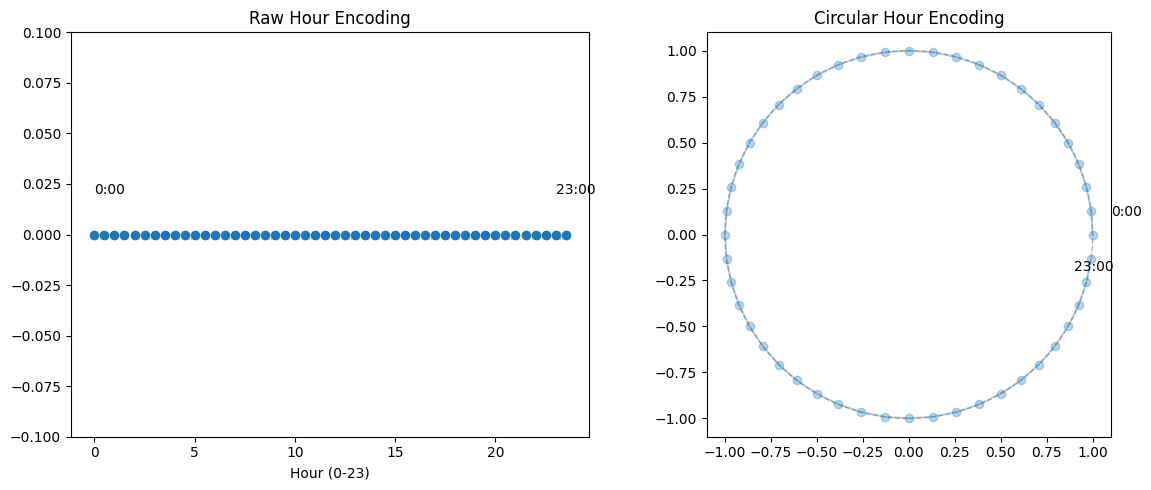

In [23]:
import matplotlib.pyplot as plt
import numpy as np

# Create a 24-hour circle
hours = np.arange(0, 24, 0.5)
hour_angles = 2 * np.pi * hours / 24
hour_x = np.cos(hour_angles)
hour_y = np.sin(hour_angles)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Raw hours (problematic!)
ax1.plot(hours, [0]*len(hours), 'o')
ax1.set_xlabel('Hour (0-23)')
ax1.set_title('Raw Hour Encoding')
ax1.annotate('0:00', (0, 0), xytext=(0, 0.02))
ax1.annotate('23:00', (23, 0), xytext=(23, 0.02))
ax1.set_ylim(-0.1, 0.1)

# Plot 2: Circular encoding (correct!)
ax2.plot(hour_x, hour_y, 'o-', alpha=0.3)
ax2.set_aspect('equal')
ax2.set_title('Circular Hour Encoding')
# Mark 0:00 and 23:00 - they're neighbors!
ax2.annotate('0:00', (1, 0), xytext=(1.1, 0.1))
ax2.annotate('23:00', (np.cos(2*np.pi*23/24), np.sin(2*np.pi*23/24)), 
             xytext=(0.9, -0.2))
ax2.add_artist(plt.Circle((0, 0), 1, fill=False, linestyle='--', alpha=0.3))

plt.tight_layout()
plt.show()

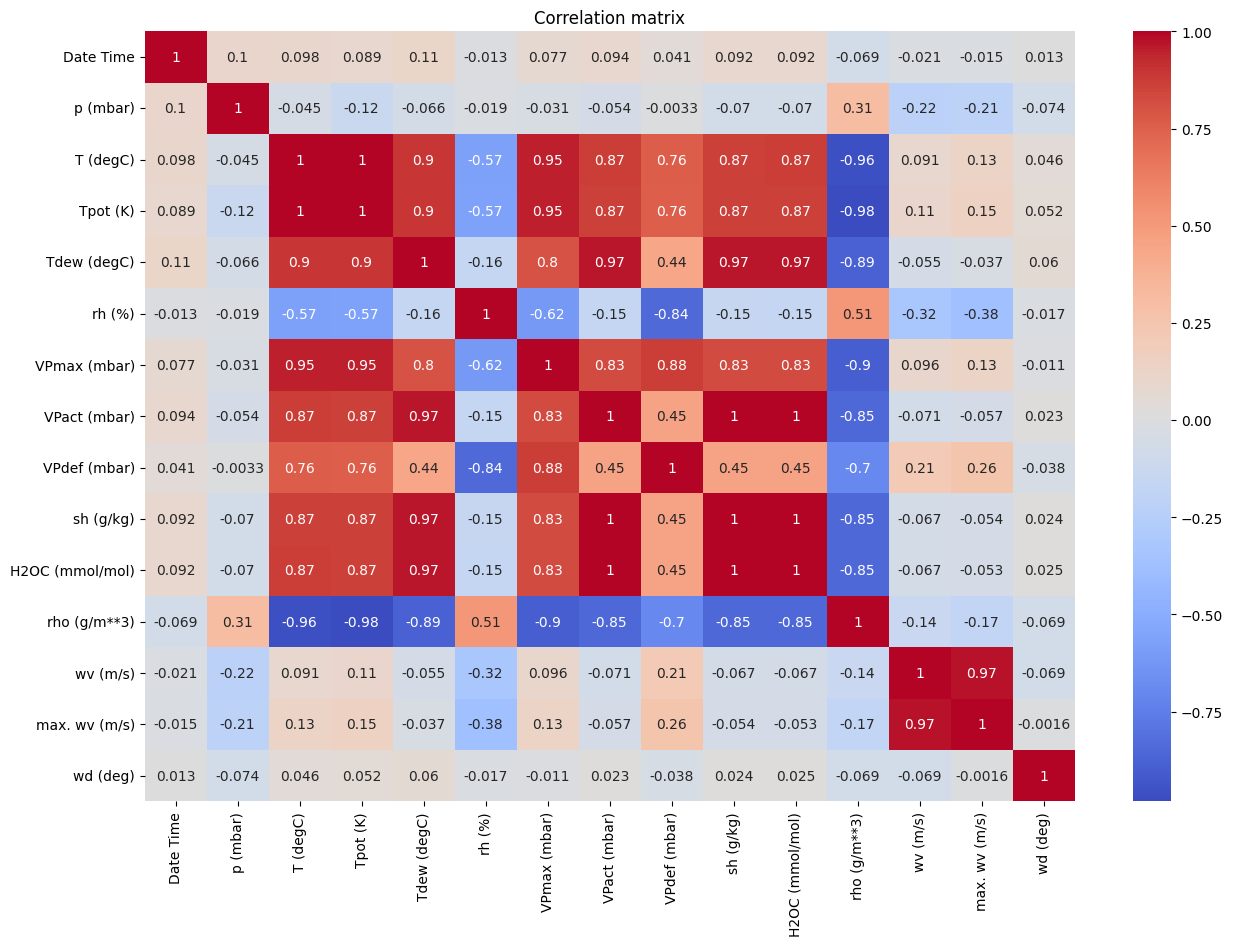

In [24]:
#heatmap to see the correlations
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize= (15 , 10))
corr_mat= df_hourly.drop(columns=['hour_sin' , 'hour_cos' , 'doy_sin' , 'doy_cos' , 'hour' ,'day_of_year']).corr()
sns.heatmap(corr_mat , cmap='coolwarm' , annot = True)
plt.title('Correlation matrix')
plt.show()

## **droping unnessecary columns (really week correlation)**

In [14]:

#Modification_3
#dropping the unnessecay cols that don't affect on out target like wd , wv also the highly correlated features like the same temp but with kilven
#abs(corr_mat['T (degC)']).sort_values()
features_to_keep = [
        'T (degC)', 'p (mbar)', 'Tdew (degC)', 'rh (%)',
        'VPmax (mbar)', 'VPact (mbar)', 'sh (g/kg)',
        'H2OC (mmol/mol)', 'rho (g/m**3)', 'wv (m/s)',
        'hour_sin', 'hour_cos', 'doy_sin', 'doy_cos'
    ]
df = df_hourly[features_to_keep]

## **splitting before normalization**

In [26]:
#after preprocessing all the data (feature eng , drop unessecary cols ) except the normalizationnnn

#TEMPORAL SPLIT first
train_size = int(len(df) * 0.7)   # 2009-2014
val_size = int(len(df) * 0.15)    # 2015
test_size = len(df) - train_size - val_size  # 2016

train_raw = df.iloc[:train_size].copy()
val_raw = df.iloc[train_size:train_size+val_size].copy()
test_raw = df.iloc[train_size+val_size:].copy()

print(f"Train: {train_raw.index[0]} to {train_raw.index[-1]}")
print(f"Val:   {val_raw.index[0]} to {val_raw.index[-1]}")
print(f"Test:  {test_raw.index[0]} to {test_raw.index[-1]}")


Train: 0 to 49089
Val:   49090 to 59608
Test:  59609 to 70128


saving data for latter use in streamlit 

In [16]:
df.to_csv('data/data_withtime_before_scaling.csv')

## **Normalization using standard scaler but on each col separetly(better results)**

In [27]:
# normalization
#normalizing each col separately and saving the scalers as i want to inverse the scalers while after the prediction

from sklearn.preprocessing import StandardScaler

# Initialize scalers (one per column)
scaler_dict = {}

# 5. Fit scalers ONLY on training data
for column in train_raw.columns:
    scaler = StandardScaler()
    scaler.fit(train_raw[[column]])  # ONLY TRAINING DATA!
    scaler_dict[column] = scaler

# 6. Transform all sets using TRAINING statistics
def scale_data(data_df, scaler_dict):
    scaled_df = pd.DataFrame(index=data_df.index)
    for column in data_df.columns:
        scaler = scaler_dict[column]
        scaled_df[column] = scaler.transform(data_df[[column]]).flatten()
    return scaled_df

train_scaled = scale_data(train_raw, scaler_dict)
val_scaled = scale_data(val_raw, scaler_dict)
test_scaled = scale_data(test_raw, scaler_dict)


In [30]:
import pickle
import json
import os

# saving scalers for streamlit app 
# creating directory for artifacts (if it doesn't exist)
artifacts_dir = 'preprocessing_artifacts'
os.makedirs(artifacts_dir, exist_ok=True)

# saving the COMPLETE scaler dictionary
with open(f'{artifacts_dir}/scaler_dict.pkl', 'wb') as f:
    pickle.dump(scaler_dict, f)

print(f"✅ Saved {len(scaler_dict)} scalers to '{artifacts_dir}/scaler_dict.pkl'")


✅ Saved 14 scalers to 'preprocessing_artifacts/scaler_dict.pkl'


### ***Verifying applying normalization approperiatly***

In [28]:
print("\n=== VERIFICATION ===")
print("Training data after scaling (should have ~mean=0, ~std=1):")
for col in ['T (degC)' , 'rh (%)']:
    print(f"  {col}: mean={train_scaled[col].mean():.6f}, std={train_scaled[col].std():.6f}")

print("\nTest data after scaling (using TRAINING statistics):")
for col in ['T (degC)','rh (%)']:
    print(f"  {col}: mean={test_scaled[col].mean():.6f}, std={test_scaled[col].std():.6f}")
    print(f"    (Note: Not exactly 0 and 1, which is CORRECT!)")


=== VERIFICATION ===
Training data after scaling (should have ~mean=0, ~std=1):
  T (degC): mean=0.000000, std=1.000010
  rh (%): mean=-0.000000, std=1.000010

Test data after scaling (using TRAINING statistics):
  T (degC): mean=0.072254, std=0.915838
    (Note: Not exactly 0 and 1, which is CORRECT!)
  rh (%): mean=0.017523, std=0.951222
    (Note: Not exactly 0 and 1, which is CORRECT!)


## ***Data Generation***

> (for predicting the temp for the next 12 h using the past 720 h (5 days)



In [29]:
from tensorflow import keras
# Parameters
sequence_length = 72   #look for the previous 72 hours 
sampling_rate = 1       
batch_size = 128
delay = 12       #predicting the next 12 ones        
target_col = 'T (degC)'  # Your target column


ImportError: cannot import name 'runtime_version' from 'google.protobuf' (c:\Users\moham\AppData\Local\Programs\Python\Python312\Lib\site-packages\google\protobuf\__init__.py)

# ***converting into numy array to be appropriate for tensorflow***

In [132]:
train_array = train_scaled.values
val_array = val_scaled.values
test_array = test_scaled.values

# Find temperature column index
target_idx = train_scaled.columns.get_loc(target_col)
print(f"Target column '{target_col}' is at index {target_idx}")

Target column 'T (degC)' is at index 0


## ***function for generation***

In [133]:
# Function to create correctly aligned datasets
def create_multivariate_dataset(data_array, target_idx, sequence_length,
                                sampling_rate, delay, batch_size, shuffle=False):
    """
    Creates multivariate time series dataset with correct alignment

    Args:
        data_array: (n_timesteps, n_features) - ALL features
        target_idx: Index of temperature column
        sequence_length: Lookback window
        sampling_rate: How often to sample
        delay: How many steps ahead to predict
        batch_size: Batch size
        shuffle: Whether to shuffle (only for training)
    """
    # Calculate total offset
    total_offset = sequence_length + delay

    # Create targets: temperature at total_offset steps ahead
    # We need to align targets with the end of each input sequence
    targets = data_array[total_offset:, target_idx]  # Only temperature!

    # Input data: everything except the last 'delay' steps
    # (because we can't predict beyond available data)
    input_data = data_array[:-delay] if delay > 0 else data_array

    # Create dataset
    dataset = keras.utils.timeseries_dataset_from_array(
        data=input_data,
        targets=targets,
        sequence_length=sequence_length,
        sampling_rate=sampling_rate,
        sequence_stride=1,
        batch_size=batch_size,
        shuffle=shuffle,
        seed=42 if shuffle else None
    )

    return dataset

## **generation step**

In [134]:

# Create datasets
print(f"\nCreating datasets with:")
print(f"  Sequence length: {sequence_length} steps ({sequence_length/144:.1f} days)")
print(f"  Sampling rate: {sampling_rate} (hourly samples)")
print(f"  Delay: {delay} steps ({delay/sampling_rate:.1f} hours ahead)")
print(f"  Batch size: {batch_size}")

train_dataset = create_multivariate_dataset(
    data_array=train_array,
    target_idx=target_idx,
    sequence_length=sequence_length,
    sampling_rate=sampling_rate,
    delay=delay,
    batch_size=batch_size,
    shuffle=True  # Only for training
)

val_dataset = create_multivariate_dataset(
    data_array=val_array,
    target_idx=target_idx,
    sequence_length=sequence_length,
    sampling_rate=sampling_rate,
    delay=delay,
    batch_size=batch_size,
    shuffle=False  # Never shuffle validation/test
)

test_dataset = create_multivariate_dataset(
    data_array=test_array,
    target_idx=target_idx,
    sequence_length=sequence_length,
    sampling_rate=sampling_rate,
    delay=delay,
    batch_size=batch_size,
    shuffle=False
)


Creating datasets with:
  Sequence length: 720 steps (5.0 days)
  Sampling rate: 6 (hourly samples)
  Delay: 72 steps (12.0 hours ahead)
  Batch size: 256


In [135]:
# 3. VERIFICATION

print("\nStep 3: Verifying datasets...")

# Check one batch from each dataset
print("\nTraining dataset:")
for batch_x, batch_y in train_dataset.take(1):
    print(f"  Batch X shape: {batch_x.shape}")  # Should be (batch, seq_len, features)
    print(f"  Batch y shape: {batch_y.shape}")  # Should be (batch,)
    print(f"  Number of features: {batch_x.shape[2]}")
    print(f"  First target (scaled temp): {batch_y[0].numpy():.3f}")

print("\nValidation dataset:")
for batch_x, batch_y in val_dataset.take(1):
    print(f"  Batch X shape: {batch_x.shape}")
    print(f"  Batch y shape: {batch_y.shape}")


Step 3: Verifying datasets...

Training dataset:
  Batch X shape: (256, 720, 13)
  Batch y shape: (256,)
  Number of features: 13
  First target (scaled temp): 0.407

Validation dataset:
  Batch X shape: (256, 720, 13)
  Batch y shape: (256,)


In [ ]:
# normalization standard scaler -> done
# outlier threshold , visulaization , nulls -> inspect , clean -> done
# splitting data (720 past , 24 future) -> done
# date generation -> done

to know the range of the test data after being horly resampled 

In [17]:
import pandas as pd
dff = pd.read_csv('data/data_withtime_before_scaling.csv')

In [19]:
dff.shape

(70129, 15)